# FINAL FANTASY VII REMAKE INTERGRADE 中古価格分析（PS5 / Switch2）

Mercari（メルカリ）日本市場の中古ソフト出品データをもとに、**FF7 リメイク インターグレード**の
PS5 版と Nintendo Switch2 版の中古価格を比較する探索的分析ノートです。

- 対象 `game_id`: `ff7r_intergrade_ps5`, `ff7r_intergrade_switch2`
- データ元: `market_listings_clean`（パイプラインで生成済みのクリーン済みテーブル）
- このノートは **読み取り専用** です。スクレイピングやパイプライン実行は行いません。

> 数値はすべて実行時に DB から読み込んだ最新データに基づきます（過去のスナップショットをハードコードしていません）。

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# macOS / Linux に入っている日本語フォントを使い、ラベルが豆腐（□）に
# ならないようにする。無ければそのまま（描画は崩れない）。
for _f in ["Hiragino Sans", "Hiragino Maru Gothic Pro", "YuGothic",
           "Noto Sans CJK JP", "IPAexGothic"]:
    if any(_f == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

## 2. データ読み込み & 品質確認

`market_listings_clean` から FF7R の 2 タイトル分を読み込み、行数・状態・コンディション・価格レンジを
ざっと確認します。

In [2]:
# notebooks/ からでもリポジトリ直下からでも DB を見つけられるように。
def find_db() -> Path:
    for base in (Path.cwd(), Path.cwd().parent):
        p = base / "data" / "mercari.sqlite"
        if p.exists():
            return p
    raise FileNotFoundError(
        "data/mercari.sqlite が見つかりません — 先に scrape / clean ステップを実行してください。"
    )

PLATFORM = {"ff7r_intergrade_ps5": "PS5", "ff7r_intergrade_switch2": "Switch2"}

conn = sqlite3.connect(find_db())
df_all = pd.read_sql_query(
    """
    SELECT game_id, listing_id, price_jpy, status_final, condition_raw,
           platform_final, title_raw, scraped_at, created_at, days_since_release
    FROM market_listings_clean
    WHERE game_id IN ('ff7r_intergrade_ps5', 'ff7r_intergrade_switch2')
    """,
    conn,
)
conn.close()

# 表示用のプラットフォーム列（game_id 由来＝データセットの区分）
df_all["platform"] = df_all["game_id"].map(PLATFORM)
print("df_all.shape:", df_all.shape)
df_all.head()

df_all.shape: (1026, 11)


,game_id,listing_id,price_jpy,status_final,condition_raw,platform_final,title_raw,scraped_at,created_at,days_since_release,platform
0,ff7r_intergrade_ps5,m65617136784,3600.0,on_sale,目立った傷や汚れなし,PS5,ファイナルファンタジー7 リメイク インターグレードPS5,2026-06-21T19:35:55.429801+00:00,2026-06-22T03:54:29.529029+00:00,1837.816614,PS5
1,ff7r_intergrade_ps5,m28801517464,3950.0,on_sale,目立った傷や汚れなし,PS5,PS5ソフト⭐︎FF7 リメイクインターグレード,2026-06-21T19:35:53.315309+00:00,2026-06-22T03:54:29.529212+00:00,1837.816589,PS5
2,ff7r_intergrade_ps5,m34677657932,4499.0,on_sale,新品、未使用,PS5,【新品】PS5 ファイナルファンタジー7 リメイク インターグレード,2026-06-21T19:35:59.654509+00:00,2026-06-22T03:54:29.529235+00:00,1837.816663,PS5
3,ff7r_intergrade_ps5,m13390890600,2980.0,sold_out,目立った傷や汚れなし,PS5,PS5 新価格版 ファイナルファンタジーVII リメイク インターグレード,2026-06-21T19:36:20.653964+00:00,2026-06-22T03:54:29.529252+00:00,1837.816906,PS5
4,ff7r_intergrade_ps5,m11933513214,3200.0,sold_out,目立った傷や汚れなし,PS5,PS5 新価格版 ファイナルファンタジーVII リメイク インターグレード,2026-06-21T19:36:29.071143+00:00,2026-06-22T03:54:29.529311+00:00,1837.817003,PS5


### データ品質メモ：プラットフォーム混入（cross-platform leakage）

PS5 版と Switch2 版で検索キーワードがほぼ共通のため、**プラットフォームが明記されていない出品** は
両方の `game_id` に候補として取り込まれます。その結果、

- `ff7r_intergrade_ps5` の中に `platform_final == 'Switch 2'` の行
- `ff7r_intergrade_switch2` の中に `platform_final == 'PS5'` の行

が一部混入しています。`market_listings_clean` の `platform_final` は詳細データ（タイトル・説明文）から
推定し直した値で、本データでは欠損（NULL）はありません。

**このノートの方針**：プラットフォーム別の分析と比較では `platform_final` を信頼できる絞り込み基準として使い、

- PS5 版 → `platform_final == 'PS5'`
- Switch2 版 → `platform_final == 'Switch 2'`

の行だけを用います（`unknown` や反対プラットフォームの行は比較から除外）。
`platform_final` が常に埋まっているため、「NULL のときだけ別フィールドで救済する」フォールバックは
今回は不要でした。下のクロス集計で混入の規模を確認できます。

In [3]:
print("=== game_id 別 行数（全クリーン行） ===")
print(df_all["game_id"].value_counts(), "\n")

print("=== platform（データセット区分） × platform_final（推定） クロス集計 ===")
print("※ 対角線以外が混入分", "\n")
print(pd.crosstab(df_all["platform"], df_all["platform_final"]), "\n")

print("=== status_final 別 件数 ===")
print(df_all.groupby("platform")["status_final"].value_counts(), "\n")

print("=== condition_raw 別 件数（上位8） ===")
print(df_all["condition_raw"].value_counts().head(8), "\n")

print("=== price_jpy の min / median / max（platform別・全行） ===")
print(df_all.groupby("platform")["price_jpy"].agg(["count", "min", "median", "mean", "max"]).round(0))

=== game_id 別 行数（全クリーン行） ===
game_id
ff7r_intergrade_switch2    550
ff7r_intergrade_ps5        476
Name: count, dtype: int64 

=== platform（データセット区分） × platform_final（推定） クロス集計 ===
※ 対角線以外が混入分 

platform_final  PS5  Switch 2  unknown
platform                              
PS5             347        52       77
Switch2          28       445       77 

=== status_final 別 件数 ===
platform  status_final
PS5       sold_out        435
          on_sale          40
          trading           1
Switch2   sold_out        502
          on_sale          47
          trading           1
Name: count, dtype: int64 

=== condition_raw 別 件数（上位8） ===
condition_raw
目立った傷や汚れなし    463
未使用に近い        321
新品、未使用        209
やや傷や汚れあり       27
傷や汚れあり          6
Name: count, dtype: int64 

=== price_jpy の min / median / max（platform別・全行） ===
          count    min  median    mean       max
platform                                        
PS5         476  300.0  3000.0  4464.0  380000.0
Switch2     550  300.0  44

In [4]:
# 混入を除いた分析用データ（platform_final で絞り込み）
df_ps5 = df_all[(df_all.game_id == "ff7r_intergrade_ps5") & (df_all.platform_final == "PS5")].copy()
df_sw2 = df_all[(df_all.game_id == "ff7r_intergrade_switch2") & (df_all.platform_final == "Switch 2")].copy()
df_ps5["platform"] = "PS5"
df_sw2["platform"] = "Switch2"
print(f"PS5版（絞り込み後）   : {len(df_ps5)} 行")
print(f"Switch2版（絞り込み後）: {len(df_sw2)} 行")

def price_hist(d, title, color="steelblue"):
    """価格ヒストグラム（500円刻み）。極端な外れ値で潰れないよう98パーセンタイル以下を表示。"""
    hi = int(np.ceil(d["price_jpy"].quantile(0.98) / 500) * 500)
    sub = d[d["price_jpy"] <= hi]
    bins = np.arange(0, hi + 500, 500)
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(sub["price_jpy"], bins=bins, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("価格（円, 500円刻み・98パーセンタイル以下を表示）")
    ax.set_ylabel("件数")
    plt.show()

PS5版（絞り込み後）   : 347 行
Switch2版（絞り込み後）: 445 行


## 3. PS5版の価格分布

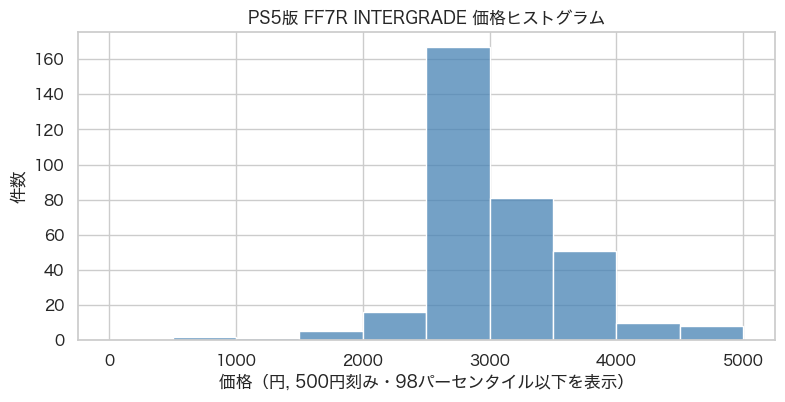

In [5]:
price_hist(df_ps5, "PS5版 FF7R INTERGRADE 価格ヒストグラム", color="steelblue")

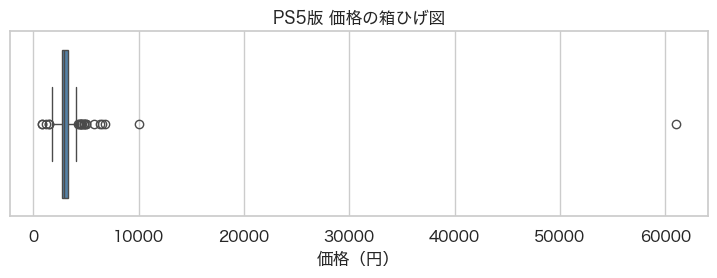

In [6]:
fig, ax = plt.subplots(figsize=(9, 2.4))
sns.boxplot(x=df_ps5["price_jpy"], color="steelblue", ax=ax)
ax.set_title("PS5版 価格の箱ひげ図")
ax.set_xlabel("価格（円）")
plt.show()

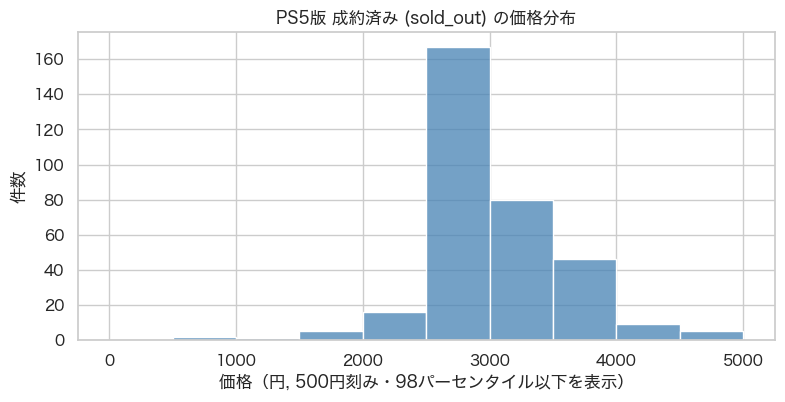

In [7]:
price_hist(df_ps5[df_ps5.status_final == "sold_out"], "PS5版 成約済み (sold_out) の価格分布", color="steelblue")

PS5 版は中央値がおおむね **3,000円前後** に集中し、価格帯は比較的タイトです。
発売から年数が経った旧世代タイトルらしく、相場は低め・安定。成約済み（sold_out）だけ見ても
分布の中心はほとんど変わらず、「売れる価格帯」がはっきりしています。

## 4. Switch2版の価格分布

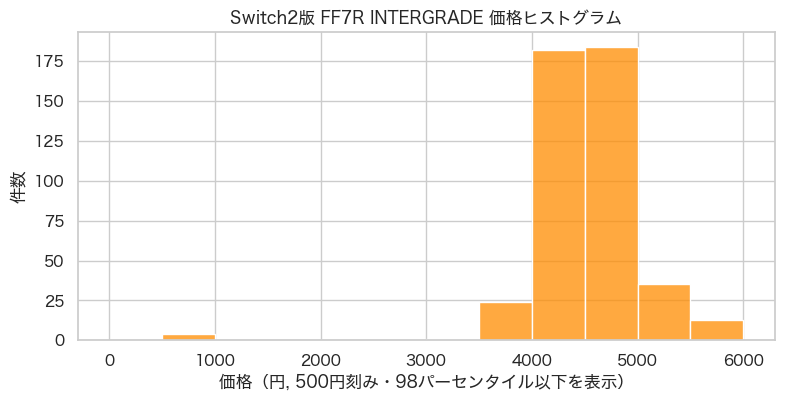

In [8]:
price_hist(df_sw2, "Switch2版 FF7R INTERGRADE 価格ヒストグラム", color="darkorange")

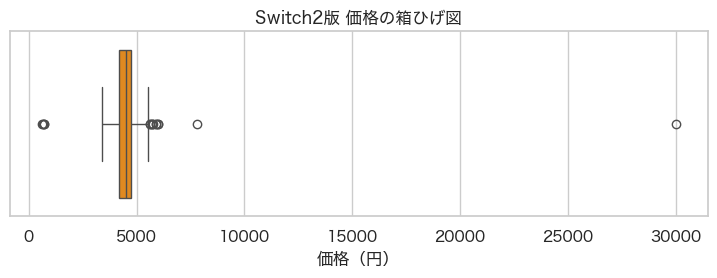

In [9]:
fig, ax = plt.subplots(figsize=(9, 2.4))
sns.boxplot(x=df_sw2["price_jpy"], color="darkorange", ax=ax)
ax.set_title("Switch2版 価格の箱ひげ図")
ax.set_xlabel("価格（円）")
plt.show()

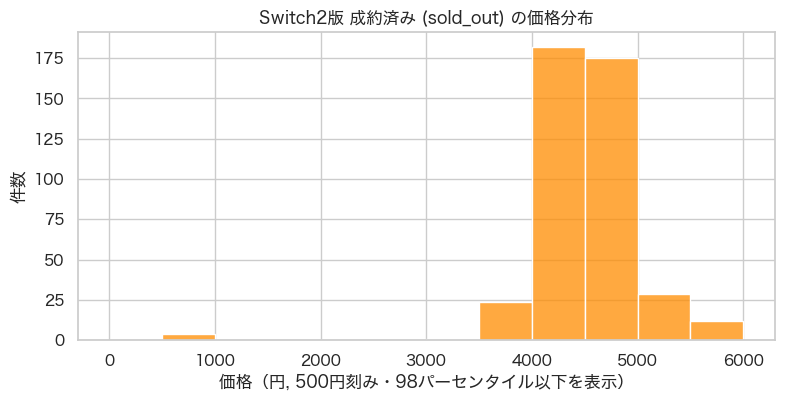

In [10]:
price_hist(df_sw2[df_sw2.status_final == "sold_out"], "Switch2版 成約済み (sold_out) の価格分布", color="darkorange")

Switch2 版は中央値が **4,500円前後** と、PS5 版より一段高い水準に山があります。
新しいプラットフォーム向けで供給がまだ少ないこと、発売が比較的最近であることが背景と考えられます。
こちらも成約済みの分布は全体とほぼ重なり、相場が安定していることを示しています。

## 5. PS5 vs Switch2 比較

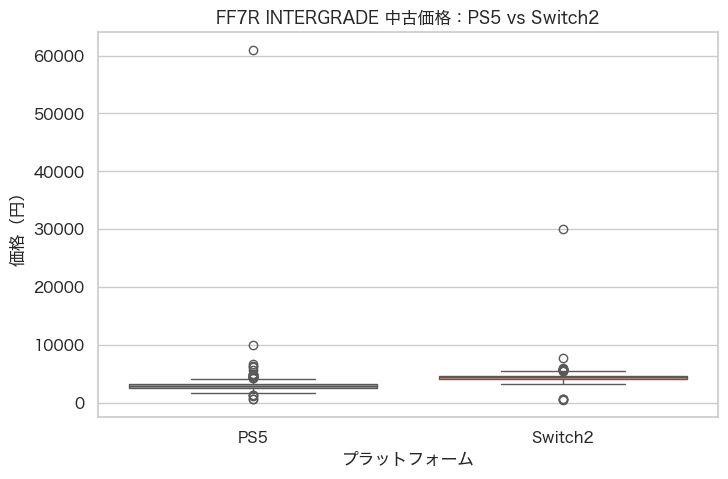

In [11]:
df_cmp = pd.concat([df_ps5, df_sw2], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_cmp, x="platform", y="price_jpy", hue="platform",
            order=["PS5", "Switch2"], palette="Set2", legend=False, ax=ax)
ax.set_title("FF7R INTERGRADE 中古価格：PS5 vs Switch2")
ax.set_xlabel("プラットフォーム")
ax.set_ylabel("価格（円）")
plt.show()

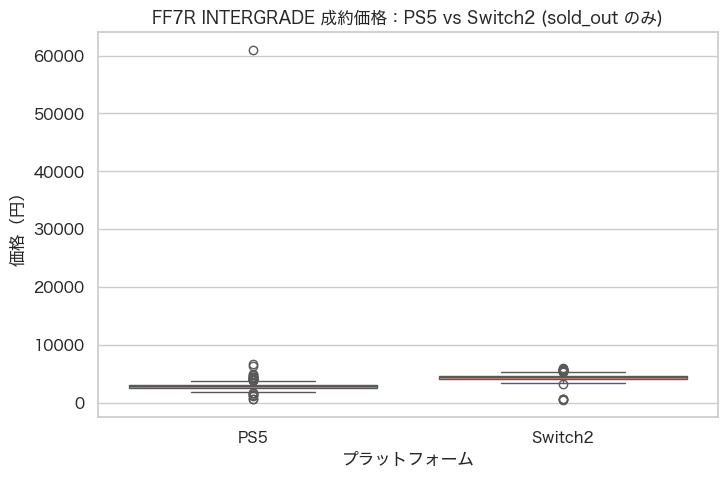

In [12]:
sold = df_cmp[df_cmp.status_final == "sold_out"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sold, x="platform", y="price_jpy", hue="platform",
            order=["PS5", "Switch2"], palette="Set2", legend=False, ax=ax)
ax.set_title("FF7R INTERGRADE 成約価格：PS5 vs Switch2 (sold_out のみ)")
ax.set_xlabel("プラットフォーム")
ax.set_ylabel("価格（円）")
plt.show()

In [13]:
def summarize(d):
    return pd.Series({
        "件数": len(d),
        "成約率": round((d["status_final"] == "sold_out").mean(), 3),
        "価格中央値": d["price_jpy"].median(),
        "平均価格": round(d["price_jpy"].mean()),
        "第1四分位": d["price_jpy"].quantile(0.25),
        "第3四分位": d["price_jpy"].quantile(0.75),
    })

summary = (df_cmp.groupby("platform", group_keys=False)[["price_jpy", "status_final"]]
           .apply(summarize)
           .reindex(["PS5", "Switch2"]))
summary.index.name = "プラットフォーム"

gap = df_sw2["price_jpy"].median() - df_ps5["price_jpy"].median()
print(f"中央値の差（Switch2 − PS5）: {gap:,.0f} 円")
summary

中央値の差（Switch2 − PS5）: 1,600 円


,件数,成約率,価格中央値,平均価格,第1四分位,第3四分位
プラットフォーム,,,,,,
PS5,347.0,0.963,2900.0,3243.0,2700.0,3300.0
Switch2,445.0,0.960,4500.0,4542.0,4200.0,4750.0


現時点のデータでは、**Switch2 版の中央値が PS5 版より約 1,600円 高い** 結果です
（PS5 ≒ 2,900円 / Switch2 ≒ 4,500円）。平均で見ても同程度の差があります。
一方で成約率はどちらも非常に高く（約 96%）、出回っている在庫はプラットフォームを問わずよく売れています。
価格差は「人気の差」というより、**世代の新しさ・供給量の差** を反映していると見るのが自然です。

## 6. 外れ値とデータ上の注意点

In [14]:
cols = ["game_id", "platform_final", "price_jpy", "status_final", "title_raw"]
print("=== 価格 上位10件（全クリーン行・絞り込み前） ===")
display(df_all.nlargest(10, "price_jpy")[cols])
print("=== 価格 下位10件（全クリーン行・絞り込み前） ===")
display(df_all.nsmallest(10, "price_jpy")[cols])

=== 価格 上位10件（全クリーン行・絞り込み前） ===


,game_id,platform_final,price_jpy,status_final,title_raw
362,ff7r_intergrade_ps5,unknown,380000.0,on_sale,ff7 REMAKE INTERGRADE シルバーネックレス
934,ff7r_intergrade_switch2,unknown,380000.0,on_sale,ff7 REMAKE INTERGRADE シルバーネックレス
372,ff7r_intergrade_ps5,PS5,61000.0,sold_out,PS5 Slim 本体 CFI-2000A01 + FF7R + 充電スタンド
264,ff7r_intergrade_ps5,unknown,41000.0,on_sale,完全未開封 スチールブックケース FF7 リメイク インターグレード ユフィ
889,ff7r_intergrade_switch2,unknown,41000.0,on_sale,完全未開封 スチールブックケース FF7 リメイク インターグレード ユフィ
10,ff7r_intergrade_ps5,unknown,30000.0,on_sale,ファイナルファンタジーVII e-store購入特典 スチールブックケース
499,ff7r_intergrade_switch2,unknown,30000.0,on_sale,ファイナルファンタジーVII e-store購入特典 スチールブックケース
12,ff7r_intergrade_ps5,Switch 2,29999.0,on_sale,【未使用】FF7 リメイク インターグレード オリジナルスチールブックケース
502,ff7r_intergrade_switch2,Switch 2,29999.0,on_sale,【未使用】FF7 リメイク インターグレード オリジナルスチールブックケース
11,ff7r_intergrade_ps5,unknown,24980.0,on_sale,ファイナルファンタジーVII リメイク インターグレード スチールブックケース


=== 価格 下位10件（全クリーン行・絞り込み前） ===


,game_id,platform_final,price_jpy,status_final,title_raw
47,ff7r_intergrade_ps5,unknown,300.0,on_sale,ff7 アートミュージアム リメイクインターグレード キービジュアル
62,ff7r_intergrade_ps5,unknown,300.0,on_sale,FINAL FANTASY VII REMAKE マグネットシート
73,ff7r_intergrade_ps5,unknown,300.0,on_sale,FINAL FANTASY VII マグネットシート
227,ff7r_intergrade_ps5,unknown,300.0,sold_out,ファイナルファンタジーVII リメイク インターグレード マグネットシート2種
383,ff7r_intergrade_ps5,unknown,300.0,sold_out,FINAL FANTASY VII REMAKE INTERGRADE
566,ff7r_intergrade_switch2,unknown,300.0,on_sale,ff7 アートミュージアム リメイクインターグレード キービジュアル
582,ff7r_intergrade_switch2,unknown,300.0,on_sale,FINAL FANTASY VII REMAKE マグネットシート
589,ff7r_intergrade_switch2,unknown,300.0,on_sale,FINAL FANTASY VII マグネットシート
854,ff7r_intergrade_switch2,unknown,300.0,sold_out,ファイナルファンタジーVII リメイク インターグレード マグネットシート2種
955,ff7r_intergrade_switch2,unknown,300.0,sold_out,FINAL FANTASY VII REMAKE INTERGRADE


上位の外れ値には、ゲームソフト本体ではない出品が混じっています。例として、

- アクセサリ・グッズ系（シルバーネックレス、缶バッジ、マグネットシート など）
- スチールブックケース単体（特典ケースのみ）
- 本体同梱・まとめ売り（PS5本体 + ソフト のセット）

といった行が高額帯に現れます。下位（数百円）側も、コードのみ・付属品のみ等の部分出品が残っている可能性があります。

キーワード除外フィルタである程度は取り除いていますが、**クリーンテーブルには
まだ少数の非ゲーム行（グッズ・バンドル・ケース単体など）が残り得る** 点に注意してください。
中央値・四分位はこうした外れ値の影響を受けにくいため、相場の中心を見るには
平均より中央値を主指標にするのが安全です。

## 7. 簡単な考察とメモ

- **PS5 版の相場の中心**：中央値はおおむね 3,000円前後。旧世代タイトルで価格は低め・安定。
- **Switch2 版の相場の中心**：中央値はおおむね 4,500円前後。PS5 版より一段高い。
- **どちらが高いか**：Switch2 版が中央値で約 1,600円 高い。世代の新しさと供給の少なさが効いていると考えられる。
- **成約率の違い**：絞り込み後はどちらも約 96% と高水準で、大きな差はない。よく回っている市場。

**次に確認したいこと**

- `platform_final == 'unknown'` 行の中身（どちらの版か判定できる手掛かりがあるか）。
- 残存するグッズ／バンドル／ケース単体行を除外キーワードで更に削れるか。
- `days_since_release` や `scraped_at` を使った時系列の価格推移（発売・再入荷イベント前後）。
- 出品コンディション（`condition_raw`）別の価格差。